# Location Share Stability Check

**Goal:** Determine whether location-level forecasts are reliable, or if we should only forecast at Region × Role level and use allocation percentages to break down by location.

**Steps:**
1. Build quarterly location-share table for each of the 51 Tier 1/2 role-level combos
2. Compute stability metrics (CV, range, std) per location-within-combo
3. Classify into confidence bands (Stable / Moderate / Unstable)
4. Trend check — detect shifting shares, use recent 4Q avg if trending
5. Build final allocation table (location %, confidence, recent-weighted or flat)
6. Summary view for leadership

**Output:** Allocation table defining what gets shown to each regional team and with what caveats.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Load Data & Rebuild Quarterly Segment Counts
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')

# Load clean data + cluster mapping
df = pd.read_pickle(os.path.join(data_dir, 'clean_42k_v1.pkl'))
mapping = pd.read_pickle(os.path.join(data_dir, 'title_to_cluster.pkl'))

# Join role_cluster
title_to_role = dict(zip(mapping['raw_title'], mapping['role_cluster']))
df['role_cluster'] = df['title'].map(title_to_role)
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['quarter'] = df['issue_date'].dt.to_period('Q')
df['location'] = df['location'].fillna('Unknown')

# Training window
train_start = pd.Period('2022Q1', freq='Q')
train_end = pd.Period('2025Q4', freq='Q')
train_quarters = sorted([q for q in df['quarter'].unique()
                          if train_start <= q <= train_end])
n_train_quarters = len(train_quarters)

# Filter to training window
df_train = df[df['quarter'].isin(train_quarters)].copy()

print(f"Training records: {len(df_train):,}")
print(f"Training window: {train_start} → {train_end} ({n_train_quarters} quarters)")
print(f"Unique role clusters: {df_train['role_cluster'].nunique()}")
print(f"Unique locations: {df_train['location'].nunique()}")

# Identify the 51 Tier 1+2 role-level combos (≥10 avg/quarter)
role_level = df_train.groupby(['region', 'role_cluster', 'quarter']).size().reset_index(name='count')
role_avg = role_level.groupby(['region', 'role_cluster'])['count'].mean().reset_index(name='avg_per_qtr')
viable_combos = role_avg[role_avg['avg_per_qtr'] >= 10].copy()
viable_combos['combo_key'] = viable_combos['region'] + ' | ' + viable_combos['role_cluster']

print(f"\nViable role-level combos (≥10 avg/qtr): {len(viable_combos)}")
print(f"  Tier 1 (≥30/qtr): {(viable_combos['avg_per_qtr'] >= 30).sum()}")
print(f"  Tier 2 (10-30/qtr): {((viable_combos['avg_per_qtr'] >= 10) & (viable_combos['avg_per_qtr'] < 30)).sum()}")

Training records: 35,718
Training window: 2022Q1 → 2025Q4 (16 quarters)
Unique role clusters: 50
Unique locations: 137

Viable role-level combos (≥10 avg/qtr): 51
  Tier 1 (≥30/qtr): 26
  Tier 2 (10-30/qtr): 25


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Build Quarterly Location-Share Table
#
# For each viable combo, compute each location's share of that
# combo's total per quarter. Filter to locations with ≥5% of
# the combo's total records (meaningful presence).
# ═══════════════════════════════════════════════════════════════

# Build full location × quarter counts for viable combos only
df_train['combo_key'] = df_train['region'] + ' | ' + df_train['role_cluster']
df_viable = df_train[df_train['combo_key'].isin(viable_combos['combo_key'])]

# Quarterly counts: combo × location × quarter
loc_qtr_counts = (
    df_viable.groupby(['combo_key', 'location', 'quarter'])
    .size()
    .reset_index(name='count')
)

# Total per combo × quarter (denominator for shares)
combo_qtr_totals = (
    df_viable.groupby(['combo_key', 'quarter'])
    .size()
    .reset_index(name='combo_total')
)

# Merge to get shares
loc_shares = loc_qtr_counts.merge(combo_qtr_totals, on=['combo_key', 'quarter'])
loc_shares['share'] = loc_shares['count'] / loc_shares['combo_total']

# Filter: only locations with ≥5% of combo's TOTAL records across all quarters
loc_total_share = (
    df_viable.groupby(['combo_key', 'location']).size()
    .reset_index(name='loc_total')
)
combo_totals = df_viable.groupby('combo_key').size().reset_index(name='combo_grand_total')
loc_total_share = loc_total_share.merge(combo_totals, on='combo_key')
loc_total_share['overall_share'] = loc_total_share['loc_total'] / loc_total_share['combo_grand_total']

# Keep only meaningful locations (≥5% of combo total)
meaningful_locs = loc_total_share[loc_total_share['overall_share'] >= 0.05][['combo_key', 'location']]

loc_shares_filtered = loc_shares.merge(meaningful_locs, on=['combo_key', 'location'])

print(f"Total location-quarter observations (all): {len(loc_shares):,}")
print(f"After ≥5% filter: {len(loc_shares_filtered):,}")
print(f"Unique combo × location pairs: {len(meaningful_locs):,}")

# How many locations per combo?
locs_per_combo = meaningful_locs.groupby('combo_key').size()
print(f"\n── Locations per combo: ──")
print(f"  Mean: {locs_per_combo.mean():.1f}")
print(f"  Median: {locs_per_combo.median():.0f}")
print(f"  Max: {locs_per_combo.max()} ({locs_per_combo.idxmax()})")
print(f"  Combos with 1 location: {(locs_per_combo == 1).sum()}")
print(f"  Combos with 2-3 locations: {((locs_per_combo >= 2) & (locs_per_combo <= 3)).sum()}")
print(f"  Combos with 4+ locations: {(locs_per_combo >= 4).sum()}")

Total location-quarter observations (all): 7,019
After ≥5% filter: 2,884
Unique combo × location pairs: 245

── Locations per combo: ──
  Mean: 4.8
  Median: 5
  Max: 8 (US | Customer Service)
  Combos with 1 location: 2
  Combos with 2-3 locations: 6
  Combos with 4+ locations: 43


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Stability Metrics per Location-Within-Combo
#
# For each location's share series across active quarters:
#   - Mean share
#   - Std deviation
#   - Coefficient of Variation (CV = std / mean)
#   - Range (max - min share)
#   - Quarters present (data density)
#
# IMPORTANT: Only compute on quarters where the COMBO had
# meaningful volume (≥5 records). Early thin quarters (2022Q1/Q2)
# would otherwise inflate CV with false zeros.
# ═══════════════════════════════════════════════════════════════

# Identify "active" quarters per combo (combo had ≥5 records that quarter)
active_quarters = combo_qtr_totals[combo_qtr_totals['combo_total'] >= 5][['combo_key', 'quarter']]

# Filter loc_shares to only active quarters
loc_shares_active = loc_shares_filtered.merge(active_quarters, on=['combo_key', 'quarter'])

# Pivot: shares only for active quarters (NaN where location had no presence)
share_pivot = loc_shares_active.pivot_table(
    index=['combo_key', 'location'],
    columns='quarter',
    values='share',
    fill_value=np.nan  # NaN, NOT 0 — absence ≠ instability
)

# For each combo×location, fill NaN with 0 ONLY for quarters where
# the combo was active (location genuinely had 0 share)
# We already filtered to active quarters, so remaining NaN = genuine 0
share_pivot = share_pivot.fillna(0)

# Count active quarters per combo (for proper denominator)
active_qtr_count = active_quarters.groupby('combo_key')['quarter'].nunique()

# Compute stability metrics (only on non-zero-padded quarters)
stability_rows = []
for (combo_key, location), shares in share_pivot.iterrows():
    # Only consider quarters that are active for this combo
    combo_active_qtrs = active_quarters[active_quarters['combo_key'] == combo_key]['quarter'].tolist()
    active_shares = shares[[q for q in shares.index if q in combo_active_qtrs]].dropna()
    
    if len(active_shares) < 4:  # need at least 4 quarters
        continue
    
    mean_s = active_shares.mean()
    std_s = active_shares.std()
    cv = std_s / mean_s if mean_s > 0 else np.inf
    min_s = active_shares.min()
    max_s = active_shares.max()
    range_pp = (max_s - min_s) * 100
    
    stability_rows.append({
        'combo_key': combo_key,
        'location': location,
        'mean_share': mean_s,
        'std_share': std_s,
        'cv': cv,
        'min_share': min_s,
        'max_share': max_s,
        'range_pct': range_pp,
        'mean_share_pct': mean_s * 100,
        'quarters_present': (active_shares > 0).sum(),
        'quarters_active': len(active_shares),
    })

stability = pd.DataFrame(stability_rows)

# Split combo_key back
stability[['region', 'role_cluster']] = stability['combo_key'].str.split(' \\| ', expand=True)

print("═"*70)
print("LOCATION SHARE STABILITY METRICS")
print("═"*70)
print(f"\nTotal location-within-combo pairs analysed: {len(stability)}")
print(f"(Filtered to combos with ≥4 active quarters per location)")

print(f"\n── CV Distribution: ──")
print(f"  Mean CV:   {stability['cv'].mean():.3f}")
print(f"  Median CV: {stability['cv'].median():.3f}")
print(f"  CV < 0.15 (stable):     {(stability['cv'] < 0.15).sum()}")
print(f"  CV 0.15-0.30 (moderate): {((stability['cv'] >= 0.15) & (stability['cv'] < 0.30)).sum()}")
print(f"  CV > 0.30 (unstable):   {(stability['cv'] >= 0.30).sum()}")

print(f"\n── Range Distribution (percentage points): ──")
print(f"  Mean range:   {stability['range_pct'].mean():.1f} pp")
print(f"  Median range: {stability['range_pct'].median():.1f} pp")
print(f"  Range < 15pp (stable):    {(stability['range_pct'] < 15).sum()}")
print(f"  Range 15-30pp (moderate): {((stability['range_pct'] >= 15) & (stability['range_pct'] < 30)).sum()}")
print(f"  Range ≥ 30pp (unstable):  {(stability['range_pct'] >= 30).sum()}")

# Show examples
print(f"\n── Most stable locations (lowest CV, share ≥10%): ──")
stable_examples = stability[stability['mean_share'] >= 0.10].nsmallest(10, 'cv')
print(f"{'Combo':<40} {'Location':<12} {'Mean%':<8} {'CV':<8} {'Range(pp)'}")
print("─"*75)
for _, r in stable_examples.iterrows():
    print(f"{r['combo_key'][:39]:<40} {r['location']:<12} "
          f"{r['mean_share_pct']:.1f}%{'':3} {r['cv']:.3f}{'':3} {r['range_pct']:.1f}")

print(f"\n── Most volatile locations (highest CV, share ≥10%): ──")
volatile_examples = stability[stability['mean_share'] >= 0.10].nlargest(10, 'cv')
print(f"{'Combo':<40} {'Location':<12} {'Mean%':<8} {'CV':<8} {'Range(pp)'}")
print("─"*75)
for _, r in volatile_examples.iterrows():
    print(f"{r['combo_key'][:39]:<40} {r['location']:<12} "
          f"{r['mean_share_pct']:.1f}%{'':3} {r['cv']:.3f}{'':3} {r['range_pct']:.1f}")

══════════════════════════════════════════════════════════════════════
LOCATION SHARE STABILITY METRICS
══════════════════════════════════════════════════════════════════════

Total location-within-combo pairs analysed: 245
(Filtered to combos with ≥4 active quarters per location)

── CV Distribution: ──
  Mean CV:   0.788
  Median CV: 0.682
  CV < 0.15 (stable):     2
  CV 0.15-0.30 (moderate): 19
  CV > 0.30 (unstable):   224

── Range Distribution (percentage points): ──
  Mean range:   31.5 pp
  Median range: 25.7 pp
  Range < 15pp (stable):    30
  Range 15-30pp (moderate): 119
  Range ≥ 30pp (unstable):  96

── Most stable locations (lowest CV, share ≥10%): ──
Combo                                    Location     Mean%    CV       Range(pp)
───────────────────────────────────────────────────────────────────────────
LATAM | Developer                        Unknown      100.0%    0.000    0.0
US | Healthcare / Clinical               CA           100.0%    0.000    0.0
US | Engineer

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Confidence Band Classification
#
# For staffing data with quarterly samples of 15-50 records,
# some share volatility is expected (sampling noise). Use
# RANGE as the primary metric — it's more interpretable and
# robust to small-sample noise.
#
# Stable:   range < 20pp — safe to allocate as point estimate
# Moderate: range 20-40pp — allocate with ±band shown
# Unstable: range ≥ 40pp — don't allocate by location
#
# Secondary filter: if CV < 0.30 despite wider range,
# upgrade from Moderate to Stable (consistent pattern).
# ═══════════════════════════════════════════════════════════════

def classify_confidence(row):
    """Classify location share into confidence bands.
    Uses range as primary metric (more robust for small samples)."""
    if row['range_pct'] < 20:
        return 'Stable'
    elif row['range_pct'] < 40:
        # If range is moderate but CV is low, it's still usable
        if row['cv'] < 0.30:
            return 'Stable'
        else:
            return 'Moderate'
    else:
        return 'Unstable'

stability['confidence'] = stability.apply(classify_confidence, axis=1)

# Summary
conf_summary = stability.groupby('confidence').agg(
    n_locations=('location', 'count'),
    avg_share=('mean_share_pct', 'mean'),
    avg_cv=('cv', 'mean'),
    avg_range=('range_pct', 'mean'),
)

print("═"*70)
print("CONFIDENCE BAND CLASSIFICATION")
print("═"*70)
print(f"\nThresholds: Stable (<20pp range), Moderate (20-40pp), Unstable (≥40pp)")
print(f"\n{'Band':<12} {'Count':<8} {'Avg Share':<12} {'Avg CV':<10} {'Avg Range':<12} {'Action'}")
print("─"*75)

actions = {
    'Stable': 'Allocate with point estimate',
    'Moderate': 'Allocate with confidence range',
    'Unstable': 'Show role-level only, no location split'
}

for band in ['Stable', 'Moderate', 'Unstable']:
    if band in conf_summary.index:
        r = conf_summary.loc[band]
        print(f"{band:<12} {r['n_locations']:<8.0f} {r['avg_share']:<12.1f} "
              f"{r['avg_cv']:<10.3f} {r['avg_range']:<12.1f} {actions[band]}")

# Per region breakdown
print(f"\n── By Region: ──")
for region in ['US', 'IN', 'LATAM']:
    region_data = stability[stability['region'] == region]
    if len(region_data) == 0:
        continue
    counts = region_data['confidence'].value_counts()
    total = len(region_data)
    stable_pct = counts.get('Stable', 0) / total * 100
    print(f"  {region}: {total} locations — "
          f"Stable: {counts.get('Stable', 0)} ({stable_pct:.0f}%), "
          f"Moderate: {counts.get('Moderate', 0)}, "
          f"Unstable: {counts.get('Unstable', 0)}")

# How many combos have at least one Stable location?
combos_with_stable = stability[stability['confidence'] == 'Stable']['combo_key'].nunique()
combos_with_any_alloc = stability[stability['confidence'].isin(['Stable', 'Moderate'])]['combo_key'].nunique()
print(f"\n── Combo coverage: ──")
print(f"  Combos with ≥1 Stable location: {combos_with_stable} / 51")
print(f"  Combos with ≥1 allocatable (Stable+Moderate): {combos_with_any_alloc} / 51")

══════════════════════════════════════════════════════════════════════
CONFIDENCE BAND CLASSIFICATION
══════════════════════════════════════════════════════════════════════

Thresholds: Stable (<20pp range), Moderate (20-40pp), Unstable (≥40pp)

Band         Count    Avg Share    Avg CV     Avg Range    Action
───────────────────────────────────────────────────────────────────────────
Stable       76       13.7         0.533      16.2         Allocate with point estimate
Moderate     114      11.8         0.896      27.5         Allocate with confidence range
Unstable     55       27.8         0.917      61.2         Show role-level only, no location split

── By Region: ──
  US: 194 locations — Stable: 72 (37%), Moderate: 101, Unstable: 21
  IN: 50 locations — Stable: 3 (6%), Moderate: 13, Unstable: 34
  LATAM: 1 locations — Stable: 1 (100%), Moderate: 0, Unstable: 0

── Combo coverage: ──
  Combos with ≥1 Stable location: 31 / 51
  Combos with ≥1 allocatable (Stable+Moderate): 49 / 5

══════════════════════════════════════════════════════════════════════
TREND ANALYSIS
══════════════════════════════════════════════════════════════════════

Locations with significant trend (>5pp change, p<0.10): 95 / 245
Locations using recent 4Q avg: 95
Locations using full 16Q avg: 150

── Trending locations: ──
Combo                               Loc        Change     Full Avg   Recent 4Q  Direction
─────────────────────────────────────────────────────────────────────────────────────
IN | Java Developer (India)         Unknown     -73.3pp    82.3%      34.6%     ↓ Declining
IN | Developer                      Unknown     -53.7pp    29.1%       2.9%     ↓ Declining
IN | HR Operations                  Unknown     -26.6pp    10.6%       0.0%     ↓ Declining
IN | Administrative Assistant       Unknown     -19.5pp     5.7%       0.0%     ↓ Declining
IN | Program Manager                Gurgaon     -12.5pp     6.5%       3.6%     ↓ Declining
IN | Developer                      Hyderabad 

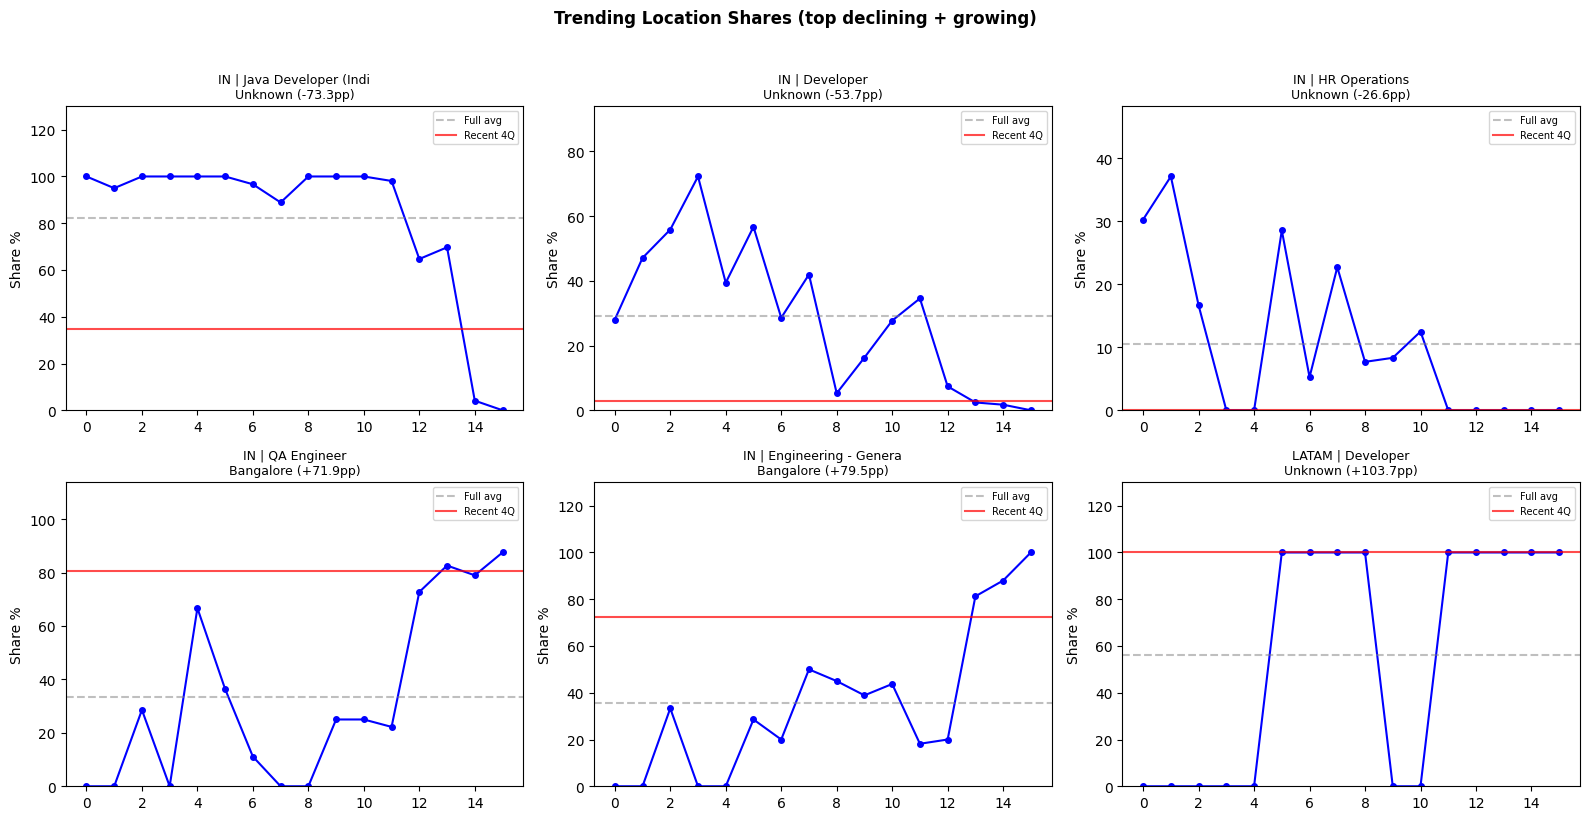

In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Trend Check on Shares
#
# A share can be "stable" on average but trending.
# Compute linear slope of share over time for each location.
# If trending significantly, use recent 4Q average instead of
# full 16Q average for allocation.
#
# "Significant trend" = slope changes share by >5pp over
# the 16-quarter window (meaningful enough to act on).
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from scipy import stats

# For each location-within-combo, compute trend (slope)
# Use the share_pivot (quarters as columns)
quarter_cols = share_pivot.columns.tolist()
x_vals = np.arange(len(quarter_cols))  # 0, 1, 2, ..., 15

trend_results = []
for idx, row in share_pivot.iterrows():
    combo_key, location = idx
    y_vals = row.values
    
    # Only compute trend if enough non-zero quarters
    non_zero = y_vals > 0
    if non_zero.sum() >= 6:  # need at least 6 quarters for meaningful trend
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
        # Total change over 16 quarters (in percentage points)
        total_change_pp = slope * (len(quarter_cols) - 1) * 100
    else:
        slope, r_value, p_value, total_change_pp = 0, 0, 1, 0
    
    # Recent 4Q average share
    recent_4q = y_vals[-4:].mean()
    full_avg = y_vals.mean()
    
    trend_results.append({
        'combo_key': combo_key,
        'location': location,
        'slope': slope,
        'r_squared': r_value**2,
        'p_value': p_value,
        'total_change_pp': total_change_pp,
        'recent_4q_share': recent_4q,
        'full_avg_share': full_avg,
    })

trend_df = pd.DataFrame(trend_results)

# Merge trend info into stability table (drop any prior trend columns for re-run safety)
trend_cols = ['slope', 'r_squared', 'p_value', 'total_change_pp', 'recent_4q_share', 'full_avg_share']
stability = stability.drop(columns=[c for c in trend_cols if c in stability.columns], errors='ignore')
stability = stability.merge(trend_df, on=['combo_key', 'location'], how='left')

# Classify trending: |total_change| > 5pp AND p < 0.10
stability['is_trending'] = (
    (stability['total_change_pp'].abs() > 5) &
    (stability['p_value'] < 0.10)
)

# For trending locations, use recent 4Q avg; otherwise use full avg
stability['allocation_share'] = np.where(
    stability['is_trending'],
    stability['recent_4q_share'],
    stability['full_avg_share']
)
stability['allocation_source'] = np.where(
    stability['is_trending'],
    'Recent 4Q',
    'Full 16Q'
)

# Summary
n_trending = stability['is_trending'].sum()
print("═"*70)
print("TREND ANALYSIS")
print("═"*70)
print(f"\nLocations with significant trend (>5pp change, p<0.10): {n_trending} / {len(stability)}")
print(f"Locations using recent 4Q avg: {n_trending}")
print(f"Locations using full 16Q avg: {len(stability) - n_trending}")

if n_trending > 0:
    trending = stability[stability['is_trending']].sort_values('total_change_pp')
    print(f"\n── Trending locations: ──")
    print(f"{'Combo':<35} {'Loc':<10} {'Change':<10} {'Full Avg':<10} {'Recent 4Q':<10} {'Direction'}")
    print("─"*85)
    for _, r in trending.iterrows():
        direction = '↑ Growing' if r['total_change_pp'] > 0 else '↓ Declining'
        print(f"{r['combo_key'][:34]:<35} {r['location']:<10} "
              f"{r['total_change_pp']:>+6.1f}pp{'':2} "
              f"{r['full_avg_share']*100:>5.1f}%{'':4} "
              f"{r['recent_4q_share']*100:>5.1f}%{'':4} {direction}")

# Plot top trending locations
if n_trending > 0:
    n_plot = min(6, n_trending)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes_flat = axes.flatten()
    
    plot_data = pd.concat([
        trending.head(3),  # most declining
        trending.tail(3),  # most growing
    ]).head(n_plot)
    
    for i, (_, row) in enumerate(plot_data.iterrows()):
        if i >= 6:
            break
        ax = axes_flat[i]
        # Get the share series for this location
        series = share_pivot.loc[(row['combo_key'], row['location'])]
        ax.plot(range(len(series)), series.values * 100, 'b-o', markersize=4)
        ax.axhline(y=row['full_avg_share']*100, color='gray', linestyle='--', alpha=0.5, label='Full avg')
        ax.axhline(y=row['recent_4q_share']*100, color='red', linestyle='-', alpha=0.7, label='Recent 4Q')
        ax.set_title(f"{row['combo_key'][:25]}\n{row['location']} ({row['total_change_pp']:+.1f}pp)",
                     fontsize=9)
        ax.set_ylabel('Share %')
        ax.legend(fontsize=7)
        ax.set_ylim(0, max(series.values * 100) * 1.3)
    
    # Hide unused axes
    for i in range(n_plot, 6):
        axes_flat[i].set_visible(False)
    
    plt.suptitle('Trending Location Shares (top declining + growing)', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Final Allocation Table
#
# For each of the 51 combos, produce:
#   - Locations to show (≥5% share, not Unstable)
#   - Allocation % (recent-weighted if trending, full avg if flat)
#   - Confidence band per location
#   - "Other" bucket for unlisted locations
# ═══════════════════════════════════════════════════════════════

# Build the allocation table
allocation_rows = []

for combo_key in viable_combos['combo_key']:
    combo_locs = stability[stability['combo_key'] == combo_key].sort_values(
        'allocation_share', ascending=False
    )
    
    # Include Stable + Moderate locations in allocation
    allocatable = combo_locs[combo_locs['confidence'].isin(['Stable', 'Moderate'])]
    
    total_alloc = allocatable['allocation_share'].sum()
    other_share = max(0, 1.0 - total_alloc)  # remainder goes to "Other"
    
    for _, loc_row in allocatable.iterrows():
        allocation_rows.append({
            'combo_key': combo_key,
            'region': loc_row['region'],
            'role_cluster': loc_row['role_cluster'],
            'location': loc_row['location'],
            'allocation_pct': loc_row['allocation_share'] * 100,
            'confidence': loc_row['confidence'],
            'source': loc_row['allocation_source'],
            'is_trending': loc_row['is_trending'],
            'cv': loc_row['cv'],
            'range_pp': loc_row['range_pct'],
        })
    
    # Add "Other" row if there's residual
    if other_share > 0.02:  # only if >2%
        # Get region from combo
        region = combo_key.split(' | ')[0]
        role = combo_key.split(' | ')[1]
        
        # Count how many unlisted locations are in this "Other" bucket
        all_combo_locs = df_viable[df_viable['combo_key'] == combo_key]['location'].nunique()
        listed_locs = len(allocatable)
        other_loc_count = all_combo_locs - listed_locs
        
        # Build descriptive label: "Other US locations (28 states, individually <5%)"
        region_labels = {'US': 'US locations', 'IN': 'India cities', 'LATAM': 'LATAM locations'}
        region_label = region_labels.get(region, f'{region} locations')
        other_label = f"Other {region_label} ({other_loc_count} individually <5% or unstable)"
        
        allocation_rows.append({
            'combo_key': combo_key,
            'region': region,
            'role_cluster': role,
            'location': other_label,
            'allocation_pct': other_share * 100,
            'confidence': 'Residual',
            'source': 'Remainder',
            'is_trending': False,
            'cv': np.nan,
            'range_pp': np.nan,
        })

alloc_table = pd.DataFrame(allocation_rows)

print("═"*70)
print("FINAL ALLOCATION TABLE")
print("═"*70)
print(f"\nTotal rows: {len(alloc_table)}")
print(f"Unique combos covered: {alloc_table['combo_key'].nunique()}")
print(f"Allocatable locations (Stable+Moderate): {len(alloc_table[alloc_table['confidence'] != 'Residual'])}")
print(f"'Other' buckets: {len(alloc_table[alloc_table['confidence'] == 'Residual'])}")

# Show a sample: top 5 combos
print(f"\n── Sample: Top 5 combos by volume ──")
top5_combos = viable_combos.nlargest(5, 'avg_per_qtr')['combo_key']
for combo in top5_combos:
    combo_alloc = alloc_table[alloc_table['combo_key'] == combo]
    print(f"\n  {combo}:")
    for _, r in combo_alloc.iterrows():
        conf_badge = f"[{r['confidence']}]"
        trend_flag = " ↗" if r['is_trending'] else ""
        print(f"    {r['location']:<20} {r['allocation_pct']:>5.1f}%  {conf_badge:<12}{trend_flag}")

══════════════════════════════════════════════════════════════════════
FINAL ALLOCATION TABLE
══════════════════════════════════════════════════════════════════════

Total rows: 240
Unique combos covered: 51
Allocatable locations (Stable+Moderate): 190
'Other' buckets: 50

── Sample: Top 5 combos by volume ──

  US | Engineering - General:
    CA                    20.3%  [Stable]     ↗
    IL                    11.3%  [Stable]    
    TX                     9.7%  [Stable]    
    WA                     9.6%  [Stable]    
    Other US locations (45 individually <5% or unstable)  49.0%  [Residual]  

  US | Operations - General:
    CA                    16.7%  [Stable]     ↗
    WA                    13.7%  [Stable]     ↗
    TX                     9.0%  [Stable]    
    IL                     8.8%  [Stable]     ↗
    NY                     8.3%  [Stable]     ↗
    IA                     6.4%  [Stable]    
    Other US locations (44 individually <5% or unstable)  37.2%  [Residual]  

 

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Leadership Summary Table & Export
#
# One consolidated table:
#   Role × Country × [Location: % share, confidence band]
# This defines what gets shown to each regional team.
# ═══════════════════════════════════════════════════════════════

print("═"*70)
print("LEADERSHIP SUMMARY — Location Allocation by Role & Region")
print("═"*70)
print(f"\nReporting grain: Region × Role Cluster (forecasted)")
print(f"  → Location breakdown where stable/moderate")
print(f"  → Role-level only where unstable")

# Summary stats
allocatable = alloc_table[alloc_table['confidence'] != 'Residual']
n_stable = (allocatable['confidence'] == 'Stable').sum()
n_moderate = (allocatable['confidence'] == 'Moderate').sum()

print(f"\n── Overall: ──")
print(f"  Total combos with location breakdown: {alloc_table['combo_key'].nunique()}")
print(f"  Location allocations (Stable): {n_stable} — show as point estimate")
print(f"  Location allocations (Moderate): {n_moderate} — show with ±range")
print(f"  'Other' buckets: {(alloc_table['confidence'] == 'Residual').sum()} — unallocated remainder")

# Compact leadership table
print(f"\n{'═'*70}")
print(f"{'Region':<6} {'Role Cluster':<32} {'Location Breakdown'}")
print("─"*70)

for region in ['US', 'IN', 'LATAM']:
    region_alloc = alloc_table[alloc_table['region'] == region]
    combos_in_region = region_alloc['combo_key'].unique()
    
    for combo in sorted(combos_in_region):
        role = combo.split(' | ')[1]
        combo_data = region_alloc[region_alloc['combo_key'] == combo]
        
        # Build location string
        loc_parts = []
        for _, r in combo_data.iterrows():
            if r['confidence'] == 'Stable':
                loc_parts.append(f"{r['location']}:{r['allocation_pct']:.0f}%")
            elif r['confidence'] == 'Moderate':
                loc_parts.append(f"{r['location']}:~{r['allocation_pct']:.0f}%")
            elif r['confidence'] == 'Residual':
                # Show shortened "Other" for compact view
                loc_parts.append(f"Other({r['allocation_pct']:.0f}%)")
        
        loc_str = ', '.join(loc_parts[:5])  # max 5 shown
        if len(loc_parts) > 5:
            loc_str += f" +{len(loc_parts)-5} more"
        
        print(f"{region:<6} {role[:31]:<32} {loc_str}")
    
    print()  # blank line between regions

# ── Export allocation table ──
export_path = os.path.join(data_dir, 'location_allocation.pkl')
alloc_table.to_pickle(export_path)

print(f"\n{'═'*70}")
print("EXPORT COMPLETE")
print(f"{'═'*70}")
print(f"\n✅ Saved: {export_path}")
print(f"   Shape: {alloc_table.shape}")
print(f"\nUsage in forecasting notebook:")
print(f"  alloc = pd.read_pickle('data/location_allocation.pkl')")
print(f"  # Apply allocation: role_forecast × location_pct = location_forecast")
print(f"\n→ Ready for 05_forecasting.ipynb")

══════════════════════════════════════════════════════════════════════
LEADERSHIP SUMMARY — Location Allocation by Role & Region
══════════════════════════════════════════════════════════════════════

Reporting grain: Region × Role Cluster (forecasted)
  → Location breakdown where stable/moderate
  → Role-level only where unstable

── Overall: ──
  Total combos with location breakdown: 51
  Location allocations (Stable): 76 — show as point estimate
  Location allocations (Moderate): 114 — show with ±range
  'Other' buckets: 50 — unallocated remainder

══════════════════════════════════════════════════════════════════════
Region Role Cluster                     Location Breakdown
──────────────────────────────────────────────────────────────────────
US     Administrative Assistant         NJ:~30%, TX:~20%, CA:~15%, NY:~13%, WA:~7% +1 more
US     Architect                        CA:~29%, NJ:~11%, OH:~10%, TX:7%, Other(43%)
US     Associate - General              IA:~13%, IL:9%, MA:8%, Ot

: 